In [20]:
import matplotlib.pyplot as plt
import numpy as np
import bayesian_average as ba
from numpy.random import normal, rand


linestyle = {"markeredgewidth":2, "elinewidth":2, "capsize":4,"markersize":3}

In [21]:
print(ba.__version__)

0.3.1


In [22]:
help(ba)

Help on package bayesian_average:

NAME
    bayesian_average

DESCRIPTION
    Python package to calculate the weighted average with Bayesian methods.
    The proposed weighted average is particularly adapted to inconsistent 
    data and/or the presence of outliers, which can both give erroneous 
    results when standard methods are used.
    For each data point, a normal distribution is considered, with the 
    provided sigma value taken as a lower bound for the *real* possibly 
    larger uncertainty sigma' and marginalising on its possible values.
    A non-informative Jeffreys' prior is considered for sigma' as default 
    (`jeffreys').
    In addition, a modified Jeffreys' prior from Sivia 2004 (`cons`), 
    the standard weighted average (`standard`) based on inverse invariance, 
    and the standard weighted average uncertainty corrected by the Birge
    (`birge`) ratio is proposed.
    
    References:
    [1] M. Trassinelli and M. Maxton, *A minimalistic and general weighte

In [23]:
ba.average?

Signature: ba.average(data, sigma, mode='jeffreys')
Docstring:
Weighted average from the inputs
    - data, an array of values
    - sigma, the corresponding associated error bars


Different type of average are available and can be select with 'mode' option.
The available ones are:

- 'jeffreys' (default): Jeffreys' weighted average proposed by Trassinelli and Maxton in 2024 (see references in README file).
The prior of the real uncertainty value is a non-informative Jeffeys' priors proportional to 1/sigma'.
This weighted average results correspond to the limit case with prior bounds [sigma, sigma_max] with sigma_max -> infinite.
The final probability distribution is, however not a proper probability distribution.

- 'cons': Conservative weighted average proposed by Sivia in 2004 (see references in README file).
The priors of the real uncertainty value are proportional to sigma_0/sigma^2, where sigma_0 is the value provided by the user
The bounds of the prior are [sigma_0, infinite].


# Synthetic tests

### Normal case

In [24]:
# # Generation random samples
mean = 1
sigma = 0.1
# s_gauss = normal(mean,sigma,20)
# sigma_array = sigma * np.ones_like(s_gauss)

# Use fixed values
s_gauss = np.array([0.99335897, 1.1323822 , 1.02411856, 0.81117013, 1.0655836 ,
       1.28094847, 1.05560916, 1.04440548, 1.15427862, 0.9276137 ,
       0.88122501, 0.97018847, 0.93392338, 0.99527202, 0.82234668,
       0.99664269, 1.04763094, 1.01472603, 1.0068966 , 1.150765  ])
sigma_array = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])


In [25]:
bayes_aver, bayes_aver_std = ba.average(s_gauss,sigma_array)
weighted_aver, weighted_aver_std = ba.average(s_gauss,sigma_array, mode= 'standard')
cons_aver, cons_aver_std = ba.average(s_gauss,sigma_array, mode= 'cons')
birge_aver, birge_aver_std = ba.average(s_gauss,sigma_array, mode= 'birge')
print("Weighted average:", round(weighted_aver,3), "+-", round(weighted_aver_std,3))
print("Bayesian average:", round(bayes_aver,3), "+-", round(bayes_aver_std,3))
print("Conservative average:", round(cons_aver,3), "+-", round(cons_aver_std,3))
print("Birge average:", round(birge_aver,3), "+-", round(birge_aver_std,3))


Birge ratio =  1.1299508728410814
Weighted average: 1.015 +- 0.022
Bayesian average: 1.013 +- 0.047
Conservative average: 1.013 +- 0.037
Birge average: 1.015 +- 0.025


In [26]:
ave = ba.average(s_gauss,sigma_array,mode='standard')
print('Inverse-variance (standard) & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss,sigma_array,mode='birge')
print('Inverse-variance with Birge ratio & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss,sigma_array,mode='cons')
print('Conservative & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss,sigma_array,mode='jeffreys')
print("Jeffreys' prior  & ",round(ave[0],3), ' & ', round(ave[1],3), r' \\')

Inverse-variance (standard) &  1.015  &  0.022  \\
Birge ratio =  1.1299508728410814
Inverse-variance with Birge ratio &  1.015  &  0.025  \\
Conservative &  1.013  &  0.037  \\
Jeffreys' prior  &  1.013  &  0.047  \\


### With "inconsistencies"

In [27]:
# s_gauss_inc = s_gauss + 10 * sigma * (rand(len(s_gauss)) - 0.5)

# Use fixed values
s_gauss_inc = np.array([1.24010346, 0.91914904, 0.5923651 , 0.86799049, 1.25413126,
       1.58817026, 0.95133397, 1.46754899, 1.01079694, 0.50040722,
       1.0645237 , 0.70381041, 1.34345954, 0.72254923, 0.62213286,
       1.46797921, 1.31214289, 0.65494835, 1.46017779, 1.07623221])
sigma_array_inc = sigma_array

In [28]:
bayes_aver_inc, bayes_aver_std_inc = ba.average(s_gauss_inc,sigma_array_inc)
weighted_aver_inc, weighted_aver_std_inc = ba.average(s_gauss_inc,sigma_array_inc, mode= 'standard')
cons_aver_inc, cons_aver_std_inc = ba.average(s_gauss_inc,sigma_array_inc, mode= 'cons')
birge_aver_inc, birge_aver_std_inc = ba.average(s_gauss_inc,sigma_array_inc, mode= 'birge')
print("Weighted average:", round(weighted_aver_inc,3), "+-", round(weighted_aver_std_inc,3))
print("Bayesian average:", round(bayes_aver_inc,3), "+-", round(bayes_aver_std_inc,3))
print("Conservative average:", round(cons_aver_inc,3), "+-", round(cons_aver_std_inc,3))
print("Birge average:", round(birge_aver_inc,3), "+-", round(birge_aver_std_inc,3))

Birge ratio =  3.385776674169345
Weighted average: 1.041 +- 0.022
Bayesian average: 1.031 +- 0.124
Conservative average: 1.04 +- 0.094
Birge average: 1.041 +- 0.076


In [29]:
ave = ba.average(s_gauss_inc,sigma_array_inc,mode='standard')
print('Inverse-variance (standard) & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss_inc,sigma_array_inc,mode='birge')
print('Inverse-variance with Birge ratio & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss_inc,sigma_array_inc,mode='cons')
print('Conservative & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss_inc,sigma_array_inc,mode='jeffreys')
print("Jeffreys' prior  & ",round(ave[0],3), ' & ', round(ave[1],3), r' \\')

Inverse-variance (standard) &  1.041  &  0.022  \\
Birge ratio =  3.385776674169345
Inverse-variance with Birge ratio &  1.041  &  0.076  \\
Conservative &  1.04  &  0.094  \\
Jeffreys' prior  &  1.031  &  0.124  \\


### With outlier

In [30]:
# s_gauss_out = np.append(s_gauss, mean + 5 * sigma)

# Use fixed values
s_gauss_out = np.array([0.99335897, 1.1323822 , 1.02411856, 0.81117013, 1.0655836 ,
       1.28094847, 1.05560916, 1.04440548, 1.15427862, 0.9276137 ,
       0.88122501, 0.97018847, 0.93392338, 0.99527202, 0.82234668,
       0.99664269, 1.04763094, 1.01472603, 1.0068966 , 1.150765  ,
       1.5       ])
sigma_array_out = np.append(sigma_array, sigma / 3)


bayes_aver_out, bayes_aver_std_out = ba.average(s_gauss_out,sigma_array_out)
weighted_aver_out, weighted_aver_std_out = ba.average(s_gauss_out,sigma_array_out, mode= 'standard')
cons_aver_out, cons_aver_std_out = ba.average(s_gauss_out,sigma_array_out, mode= 'cons')
birge_aver_out, birge_aver_std_out = ba.average(s_gauss_out,sigma_array_out, mode= 'birge')
print("Weighted average:", round(weighted_aver_out,3), "+-", round(weighted_aver_std_out,3))
print("Bayesian average:", round(bayes_aver_out,3), "+-", round(bayes_aver_std_out,3))
print("Conservative average:", round(cons_aver_out,3), "+-", round(cons_aver_std_out,3))
print("Birge average:", round(birge_aver_out,3), "+-", round(birge_aver_std_out,3))

Birge ratio =  2.9153673144011556
Weighted average: 1.166 +- 0.019
Bayesian average: 1.018 +- 0.047
Conservative average: 1.019 +- 0.037
Birge average: 1.166 +- 0.054


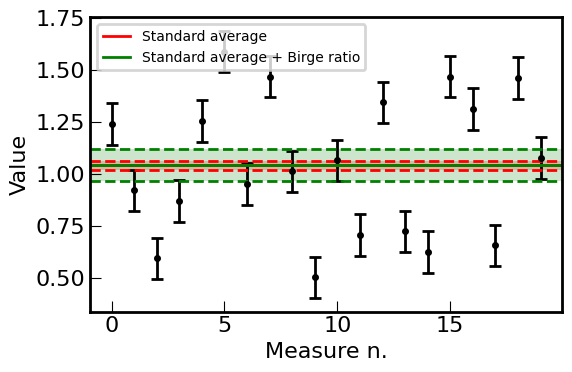

In [31]:
ax1 = plt.figure(figsize=(6,4))
plt.errorbar(range(len(s_gauss_inc)), s_gauss_inc, yerr = sigma_array_inc, fmt='ok',ecolor='k',mec='k',ls = "",**linestyle)
plt.ylabel('Value')
plt.xlabel('Measure n.')
plt.axhline(weighted_aver_inc, c = "r", label = "Standard average")
plt.axhline(weighted_aver_inc - weighted_aver_std_inc, color = "r", ls = "--")
plt.axhline(weighted_aver_inc + weighted_aver_std_inc, color = "r", ls = "--")
plt.axhspan(weighted_aver_inc - weighted_aver_std_inc,weighted_aver_inc + weighted_aver_std_inc, alpha=0.2, facecolor='r')
plt.axhline(birge_aver_inc, c = "green", label = "Standard average + Birge ratio")
plt.axhline(birge_aver_inc - birge_aver_std_inc, color = "green", ls = "--")
plt.axhline(birge_aver_inc + birge_aver_std_inc, color = "green", ls = "--")
plt.axhspan(birge_aver_inc - birge_aver_std_inc,birge_aver_inc + birge_aver_std_inc, alpha=0.2, facecolor='green')
#ax1.set_xlabel("Sort number")
#ax1.set_ylabel("Value")
plt.legend(loc = "upper left",fontsize=10)
plt.tight_layout()
# plt.savefig('synthetic_inc_swa_bwa.pdf')

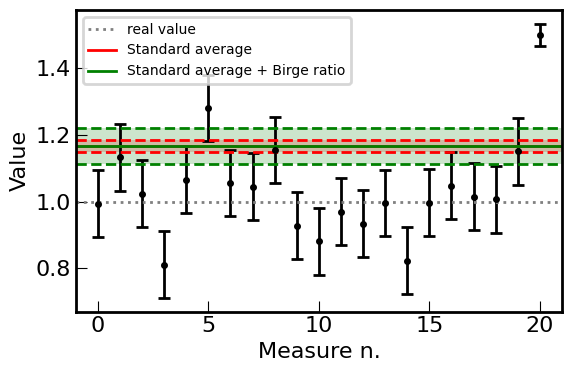

In [32]:
plt.figure(figsize=(6,4))
plt.errorbar(range(len(s_gauss_out)), s_gauss_out, yerr = sigma_array_out, fmt='ok',ecolor='k',mec='k',ls = "",**linestyle)
plt.ylabel('Value')
plt.xlabel('Measure n.')
plt.axhline(1.0, color = "gray", ls = ":", label = "real value")
plt.axhline(weighted_aver_out, c = "r", label = "Standard average")
plt.axhline(weighted_aver_out - weighted_aver_std_out, color = "r", ls = "--")
plt.axhline(weighted_aver_out + weighted_aver_std_out, color = "r", ls = "--")
plt.axhspan(weighted_aver_out - weighted_aver_std_out,weighted_aver_out + weighted_aver_std_out, alpha=0.2, facecolor='r')
plt.axhline(birge_aver_out, c = "green", label = "Standard average + Birge ratio")
plt.axhline(birge_aver_out - birge_aver_std_out, color = "green", ls = "--")
plt.axhline(birge_aver_out + birge_aver_std_out, color = "green", ls = "--")
plt.axhspan(birge_aver_out - birge_aver_std_out,birge_aver_out + birge_aver_std_out, alpha=0.2, facecolor='green')
plt.legend(loc = "upper left",fontsize=10)
plt.tight_layout()
# plt.savefig('synthetic_out_swa_bwa.pdf')

In [33]:
ba.average(s_gauss_out,sigma_array_out,mode='birge')

Birge ratio =  2.9153673144011556


(np.float64(1.1658305417241377), np.float64(0.05413701193580461))

In [34]:
ave = ba.average(s_gauss_out,sigma_array_out,mode='standard')
print('Inverse-variance (standard) & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss_out,sigma_array_out,mode='birge')
print('Inverse-variance with Birge ratio & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss_out,sigma_array_out,mode='cons')
print('Conservative & ',round(ave[0],3), ' & ', round(ave[1],3), r' \\')
ave = ba.average(s_gauss_out,sigma_array_out,mode='jeffreys')
print("Jeffreys' prior  & ",round(ave[0],3), ' & ', round(ave[1],3), r' \\')



Inverse-variance (standard) &  1.166  &  0.019  \\
Birge ratio =  2.9153673144011556
Inverse-variance with Birge ratio &  1.166  &  0.054  \\
Conservative &  1.019  &  0.037  \\
Jeffreys' prior  &  1.018  &  0.047  \\


Jeffreys' weighted average: 1.0176330004890344 +- 0.047454079589557996
Conservative weighted average: 1.0187428971196735 +- 0.036964073873335584
Standard weighted average: 1.1658305417241377 +- 0.018569533817705187


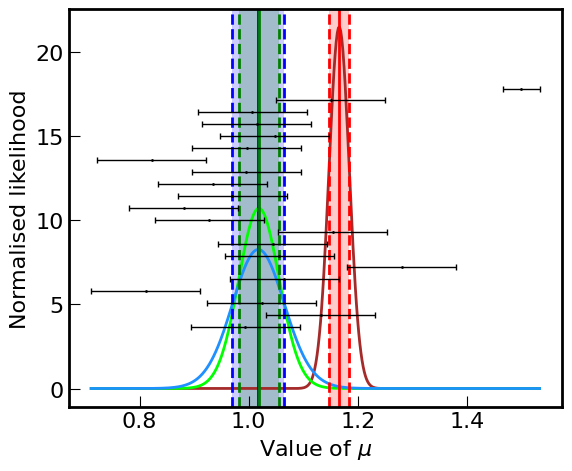

In [35]:
plt.figure(figsize=(6,5))
ba.plot_average(s_gauss_out,sigma_array_out,plot_data=True,
                standard_val=True,standard_like=True,
                cons_val=True, cons_like=True,linear=True,normalize=True)
#plt.ylim(0,0.20)
#plt.legend(loc="upper left",fontsize=10,fancybox=True, framealpha=1)
plt.legend('',frameon=False)
plt.xlabel('Value of $\mu$')
plt.ylabel('Normalised likelihood')
#plt.ylim(-2,27)
plt.tight_layout()
# plt.savefig('outlier_new.pdf')

Jeffreys' weighted average: 1.0307278911810032 +- 0.12423372382740715
Conservative weighted average: 1.0399918791300549 +- 0.09426141265095551
Standard weighted average: 1.040997646 +- 0.0223606797749979


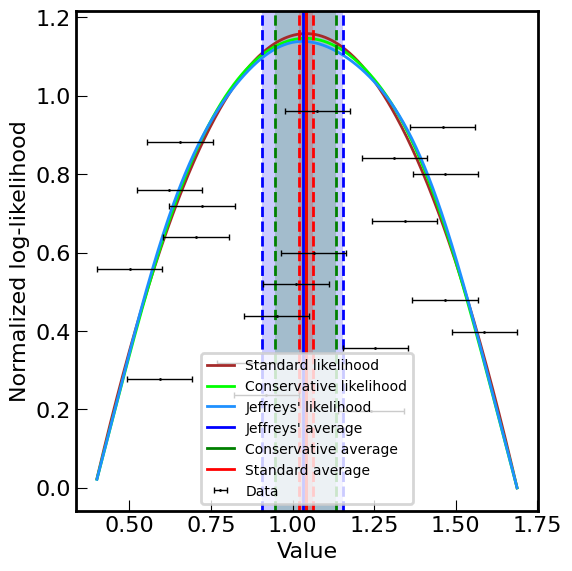

In [36]:
plt.figure(figsize=(6,6))
ba.plot_average(s_gauss_inc,sigma_array_inc,plot_data=True,
                standard_val=True,standard_like=True,
                cons_val=True, cons_like=True,normalize=True)
#plt.ylim(0,0.024)
plt.legend(fontsize=10)
plt.xlabel('Value')
plt.tight_layout()

In [37]:
data = np.array([1.0,1.1,1.2,1.3,1.9])
sigma = np.array([0.2,0.2,0.2,0.2,0.02])

<lambdifygenerated-50>:2: RuntimeWarning: divide by zero encountered in log
  return log(2.5*sqrt(2)*exp(-12.5*(1.0 - mu)**2)/sqrt(pi)) + log(2.5*sqrt(2)*exp(-15.125*(1 - 0.909090909090909*mu)**2)/sqrt(pi)) + log(2.5*sqrt(2)*exp(-18.0*(1 - 0.833333333333333*mu)**2)/sqrt(pi)) + log(2.5*sqrt(2)*exp(-21.125*(1 - 0.769230769230769*mu)**2)/sqrt(pi)) + log(25.0*sqrt(2)*exp(-4512.5*(1 - 0.526315789473684*mu)**2)/sqrt(pi))
<lambdifygenerated-53>:2: RuntimeWarning: invalid value encountered in divide
  return -log(erf(2.5*sqrt(2)*(1.0 - mu))/(1.0 - mu)) - log(erf(2.5*sqrt(2)*(1.1 - mu))/(1.1 - mu)) - log(erf(2.5*sqrt(2)*(1.2 - mu))/(1.2 - mu)) - log(erf(2.5*sqrt(2)*(1.3 - mu))/(1.3 - mu)) - log(erf(25.0*sqrt(2)*(1.9 - mu))/(1.9 - mu))


Jeffreys' weighted average: 1.1989839897741537 +- 0.19373024433860053
Conservative weighted average: 1.2137872946095953 +- 0.15690073077151948
Standard weighted average: 1.8711538461538462 +- 0.019611613513818404


<lambdifygenerated-54>:2: RuntimeWarning: divide by zero encountered in log
  return -log((1 - exp(-12.5*(1.0 - mu)**2))/(1.0 - mu)**2) - log(0.826446280991735*(1 - exp(-15.125*(1 - 0.909090909090909*mu)**2))/(1 - 0.909090909090909*mu)**2) - log(0.694444444444444*(1 - exp(-18.0*(1 - 0.833333333333333*mu)**2))/(1 - 0.833333333333333*mu)**2) - log(0.591715976331361*(1 - exp(-21.125*(1 - 0.769230769230769*mu)**2))/(1 - 0.769230769230769*mu)**2) - log(0.277008310249307*(1 - exp(-4512.5*(1 - 0.526315789473684*mu)**2))/(1 - 0.526315789473684*mu)**2)
/opt/homebrew/lib/python3.11/site-packages/scipy/optimize/_linesearch.py:161: RuntimeWarning: invalid value encountered in scalar subtract
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/opt/homebrew/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:574: RuntimeWarning: invalid value encountered in subtract
  dx = ((x0 + h) - x0)
/opt/homebrew/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:685: RuntimeWarning: invalid value 

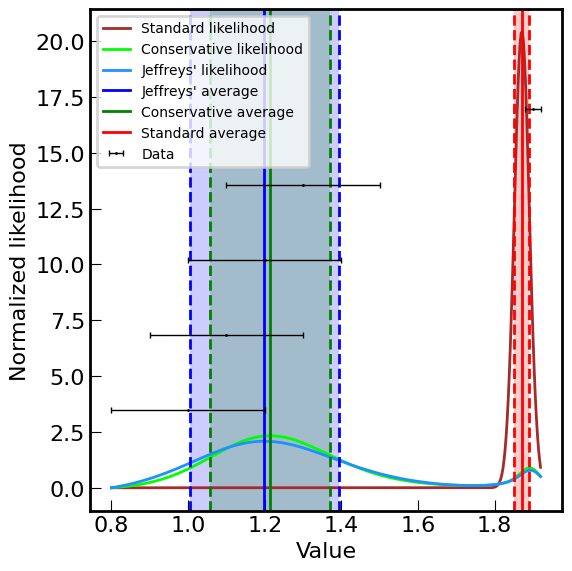

In [38]:
plt.figure(figsize=(6,6))
ba.plot_average(data,sigma,plot_data=True,
                standard_val=True,standard_like=True,
                cons_val=True, cons_like=True,linear=True,normalize=True)
#plt.ylim(0,0.026)
plt.legend(fontsize=10)
plt.xlabel('Value')
plt.tight_layout()